# EV Charging & Grid Optimization - Data Cleaning and Preprocessing
**Author:** Min Thant (Data Loading & Cleaning)

This notebook focuses on the cleaning and preprocessing of the EV charging dataset. We implement robust imputation techniques (SimpleImputer and KNNImputer) to handle any potential missing values and prepare the data for downstream analysis and modeling.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder

In [20]:

# 1. Load the dataset
file_path = 'ev_charging.csv'
df = pd.read_csv(file_path)

print(f"Initial Dataset Shape: {df.shape}")
df.head(10)

Initial Dataset Shape: (8354, 27)


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,1/1/2025 0:00,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,1/1/2025 0:15,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,1/1/2025 0:30,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,1/1/2025 0:45,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,1/1/2025 1:00,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466
5,1/1/2025 1:15,ST014,Highway,EV10005,Bus,1/1/2025 1:15,1/1/2025 1:18,1/1/2025 2:15,3,75,...,14.61,0.353360,Low,Clear,Wednesday,Off-Peak,22.889886,CH4,Medium,3.517468
6,1/1/2025 1:30,ST004,Urban,EV10006,Bus,1/1/2025 1:30,1/1/2025 1:51,1/1/2025 2:23,21,30,...,5.16,0.227020,Low,Clear,Wednesday,Off-Peak,14.254154,CH6,Medium,-18.250454
7,1/1/2025 1:45,ST020,Highway,EV10007,Car,1/1/2025 1:45,1/1/2025 1:49,1/1/2025 2:51,4,60,...,8.58,0.134761,Low,Rainy,Wednesday,Off-Peak,22.111927,CH8,High,-7.153357
8,1/1/2025 2:00,ST004,Highway,EV10008,Car,1/1/2025 2:00,1/1/2025 2:02,1/1/2025 3:11,2,100,...,14.72,0.354674,Low,Rainy,Wednesday,Off-Peak,25.875833,CH5,High,0.908517
9,1/1/2025 2:15,ST020,Highway,EV10009,Two-Wheeler,1/1/2025 2:15,1/1/2025 2:16,1/1/2025 3:59,1,60,...,13.96,0.242611,Low,Clear,Wednesday,Off-Peak,16.667140,CH2,Low,2.071455


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

In [22]:
df.describe()

,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward
count,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000
mean,9.526335,61.079722,34.808452,98.495545,39.079746,22.449126,178.700376,4.591573,53.177399,9.959945,0.354101,53.156126,-11.834559
std,4.894049,25.001163,14.478839,3.258039,18.973883,16.813449,149.120567,2.828987,27.380740,2.878798,0.186150,27.563387,9.271940
min,0.000000,30.000000,10.000582,65.079759,7.502195,7.000000,10.000000,0.000000,10.053024,5.000000,0.100157,5.505723,-43.285910
25%,6.000000,40.000000,22.371986,98.463666,23.675251,11.000000,64.118008,3.000000,28.029710,7.510000,0.207315,27.911603,-18.354606
50%,9.000000,60.000000,34.638994,99.998223,35.148384,11.000000,133.700252,5.000000,49.421293,9.955000,0.313459,49.513337,-11.268337
75%,13.000000,75.000000,47.310647,100.000000,51.363447,22.000000,247.946169,7.000000,77.600445,12.397500,0.462315,77.845036,-5.106912
max,28.000000,100.000000,59.992462,100.000000,89.929089,50.000000,776.551110,15.000000,100.000000,15.000000,0.799922,104.985659,14.176434


In [23]:
df.isnull().sum()

timestamp                 0
station_id                0
location_type             0
vehicle_id                0
vehicle_type              0
arrival_time              0
charging_start_time       0
charging_end_time         0
waiting_time              0
battery_capacity_kWh      0
initial_soc               0
final_soc                 0
energy_consumed_kWh       0
charging_power_kW         0
charging_duration         0
queue_length              0
station_load              0
electricity_price         0
renewable_energy_ratio    0
traffic_density           0
weather_condition         0
day_of_week               0
time_slot                 0
charging_demand           0
assigned_charger_id       0
charging_priority         0
optimization_reward       0
dtype: int64

### 2. Basic Cleaning and Sorting
We convert timestamps and sort the data chronologically.

In [24]:
date_cols = ["timestamp", "arrival_time", "charging_start_time", "charging_end_time"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df = df.sort_values("timestamp").reset_index(drop=True)
print("Datetime conversion and sorting complete.")

Datetime conversion and sorting complete.


In [25]:
df.head(10)

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466
5,2025-01-01 01:15:00,ST014,Highway,EV10005,Bus,2025-01-01 01:15:00,2025-01-01 01:18:00,2025-01-01 02:15:00,3,75,...,14.61,0.353360,Low,Clear,Wednesday,Off-Peak,22.889886,CH4,Medium,3.517468
6,2025-01-01 01:30:00,ST004,Urban,EV10006,Bus,2025-01-01 01:30:00,2025-01-01 01:51:00,2025-01-01 02:23:00,21,30,...,5.16,0.227020,Low,Clear,Wednesday,Off-Peak,14.254154,CH6,Medium,-18.250454
7,2025-01-01 01:45:00,ST020,Highway,EV10007,Car,2025-01-01 01:45:00,2025-01-01 01:49:00,2025-01-01 02:51:00,4,60,...,8.58,0.134761,Low,Rainy,Wednesday,Off-Peak,22.111927,CH8,High,-7.153357
8,2025-01-01 02:00:00,ST004,Highway,EV10008,Car,2025-01-01 02:00:00,2025-01-01 02:02:00,2025-01-01 03:11:00,2,100,...,14.72,0.354674,Low,Rainy,Wednesday,Off-Peak,25.875833,CH5,High,0.908517
9,2025-01-01 02:15:00,ST020,Highway,EV10009,Two-Wheeler,2025-01-01 02:15:00,2025-01-01 02:16:00,2025-01-01 03:59:00,1,60,...,13.96,0.242611,Low,Clear,Wednesday,Off-Peak,16.667140,CH2,Low,2.071455


### 3. Feature Selection
Removing unique identifiers that don't contribute to the time-series patterns.

In [31]:
cols_to_drop = ['vehicle_id', 'assigned_charger_id', 'station_id']
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['vehicle_id', 'assigned_charger_id', 'station_id']


### 4. Data Imputation
Although the current dataset is clean (0 missing values), we implement a pipeline using `SimpleImputer` and `KNNImputer` to handle future data drift or missing entries in real-time streams.

In [32]:
# Identify numerical and categorical columns
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_cleaned.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns.tolist()

print(f"Numerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}")


Numerical Columns: ['waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'charging_demand', 'optimization_reward']
Categorical Columns: ['location_type', 'vehicle_type', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'charging_priority']


In [33]:
df_cleaned.head(10)

,timestamp,location_type,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,...,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,charging_priority,optimization_reward
0,2025-01-01 00:00:00,Urban,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,48.984550,99.865576,...,15.161672,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,Low,-8.622299
1,2025-01-01 00:15:00,Urban,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,58.495493,100.000000,...,20.997219,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,Low,-1.935644
2,2025-01-01 00:30:00,Highway,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,35.711722,95.733464,...,31.606151,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,Low,-18.201846
3,2025-01-01 00:45:00,Urban,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,29.270825,100.000000,...,21.803050,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,Medium,-7.404018
4,2025-01-01 01:00:00,Highway,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,25.585554,100.000000,...,15.626266,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,Low,-6.577466
5,2025-01-01 01:15:00,Highway,Bus,2025-01-01 01:15:00,2025-01-01 01:18:00,2025-01-01 02:15:00,3,75,39.894999,100.000000,...,20.416685,14.61,0.353360,Low,Clear,Wednesday,Off-Peak,22.889886,Medium,3.517468
6,2025-01-01 01:30:00,Urban,Bus,2025-01-01 01:30:00,2025-01-01 01:51:00,2025-01-01 02:23:00,21,30,24.046725,100.000000,...,15.305339,5.16,0.227020,Low,Clear,Wednesday,Off-Peak,14.254154,Medium,-18.250454
7,2025-01-01 01:45:00,Highway,Car,2025-01-01 01:45:00,2025-01-01 01:49:00,2025-01-01 02:51:00,4,60,19.942120,100.000000,...,18.480893,8.58,0.134761,Low,Rainy,Wednesday,Off-Peak,22.111927,High,-7.153357
8,2025-01-01 02:00:00,Highway,Car,2025-01-01 02:00:00,2025-01-01 02:02:00,2025-01-01 03:11:00,2,100,46.480309,100.000000,...,23.658538,14.72,0.354674,Low,Rainy,Wednesday,Off-Peak,25.875833,High,0.908517
9,2025-01-01 02:15:00,Highway,Two-Wheeler,2025-01-01 02:15:00,2025-01-01 02:16:00,2025-01-01 03:59:00,1,60,36.136641,99.540035,...,16.034384,13.96,0.242611,Low,Clear,Wednesday,Off-Peak,16.667140,Low,2.071455


### 5. Final Output
Saving the preprocessed dataset for Simon's EDA and Liam's Modelling.

In [34]:
output_file = 'preprocessed_ev_data.csv'
df_cleaned.to_csv(output_file, index=False)
print(f"Successfully saved preprocessed data to {output_file}")

Successfully saved preprocessed data to preprocessed_ev_data.csv


6. Exploratory Data Analysis

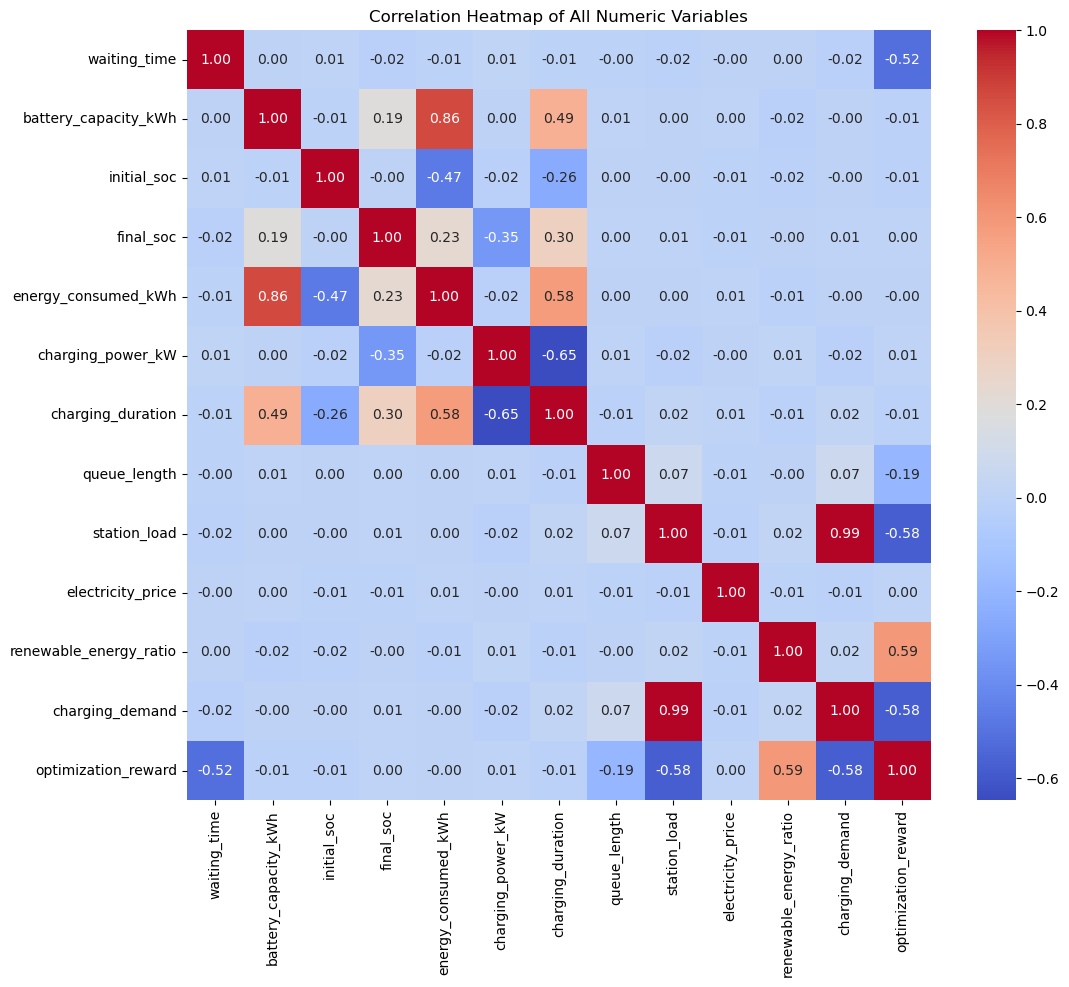

In [36]:
#Heatmap for Numeric Columns 

numeric_cols = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of All Numeric Variables')
plt.savefig('full_numeric_heatmap.png')
plt.show()

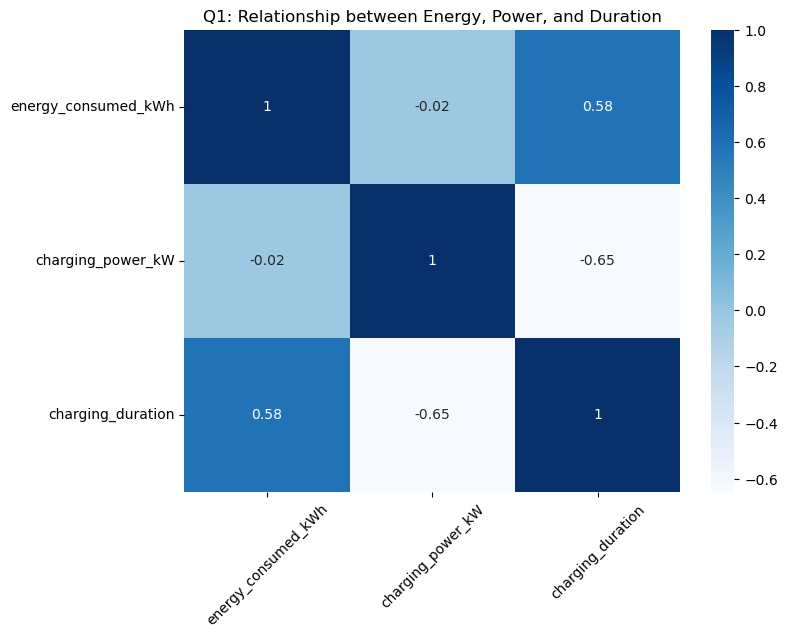

In [49]:
#Q1. How strongly are energy_consumed_kWh, charging_power_kW, and charging_duration correlated?

q1_cols = ['energy_consumed_kWh', 'charging_power_kW', 'charging_duration']
plt.figure(figsize=(8, 6))
sns.heatmap(df[q1_cols].corr(), annot=True, cmap='Blues')
plt.title('Q1: Relationship between Energy, Power, and Duration')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


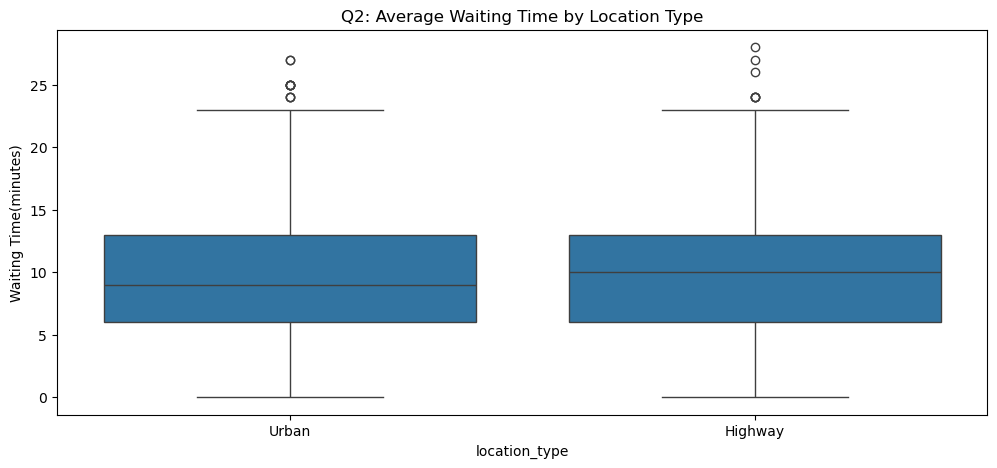

In [53]:
#Q2. Does location_type (Urban vs. Highway) significantly affect waiting_time and queue_length?

plt.figure(figsize=(12, 5))
boxplot = sns.boxplot(df_cleaned, x = 'location_type', y= 'waiting_time')
plt.title('Q2: Average Waiting Time by Location Type')
plt.ylabel('Waiting Time(minutes)')
plt.show()

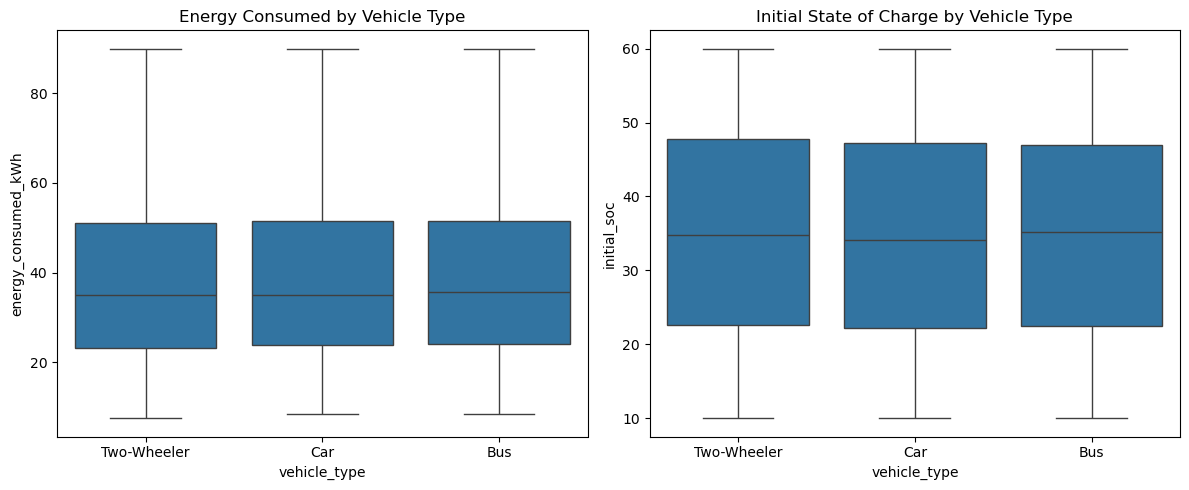

In [56]:
#Q3. How does vehicle_type (e.g., Car, Bus, Two-Wheeler) relate to the energy_consumed_kWh and the initial_soc?

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(df_cleaned, x='vehicle_type', y='energy_consumed_kWh')
plt.title('Energy Consumed by Vehicle Type')    
plt.subplot(1,2,2)
sns.boxplot(df_cleaned, x='vehicle_type', y='initial_soc')
plt.title('Initial State of Charge by Vehicle Type')
plt.tight_layout()
plt.show()

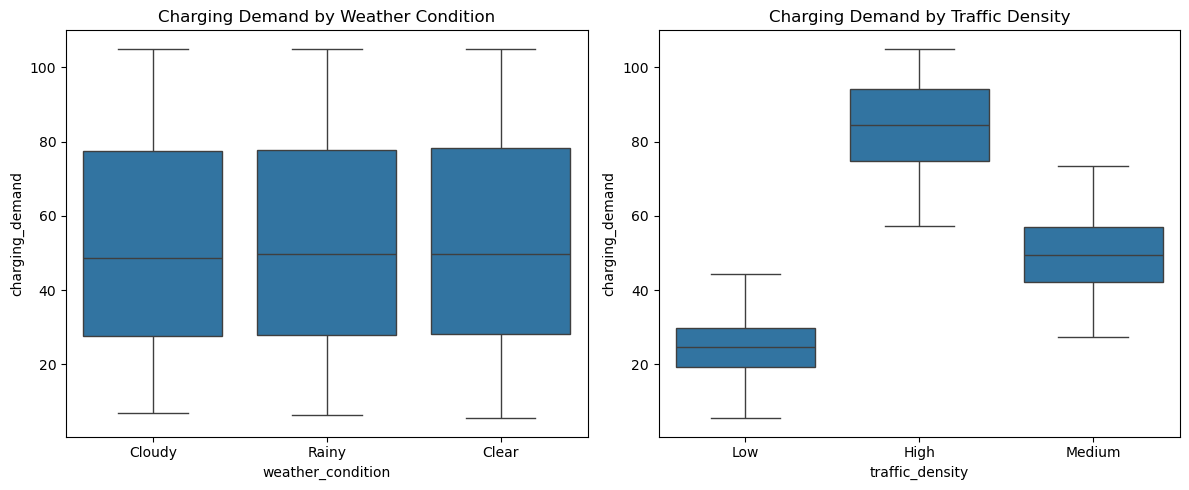

In [57]:
#Q4. What is the relationship between weather_condition, traffic_density, and the resulting charging_demand?

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(df_cleaned, x='weather_condition', y='charging_demand')
plt.title('Charging Demand by Weather Condition')
plt.subplot(1,2,2)
sns.boxplot(df_cleaned, x='traffic_density', y='charging_demand')
plt.title('Charging Demand by Traffic Density')
plt.tight_layout()
plt.show()

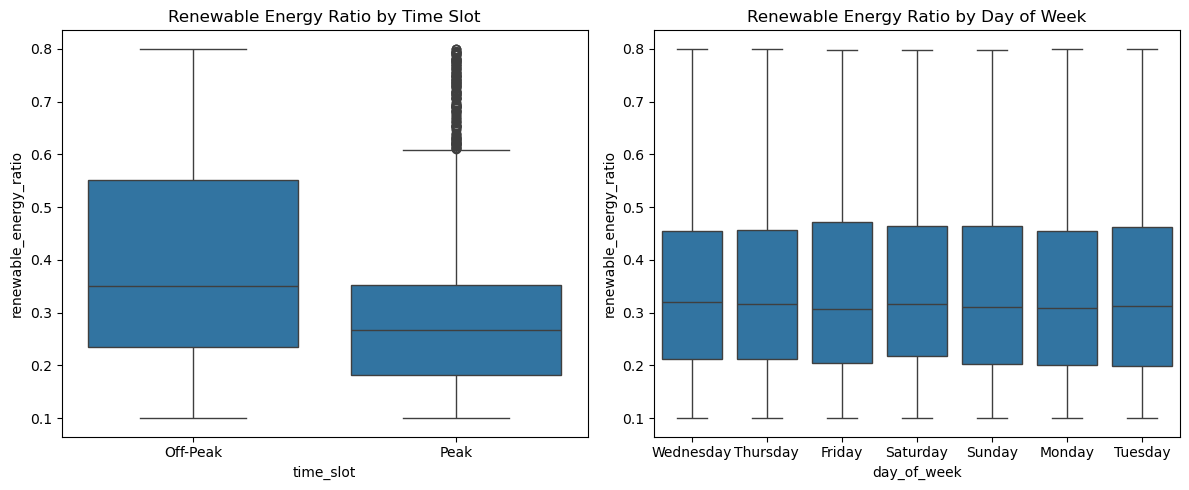

In [58]:
#Q5. How does the renewable_energy_ratio fluctuate across different time_slot and day_of_week categories?

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(df_cleaned, x='time_slot', y='renewable_energy_ratio')
plt.title('Renewable Energy Ratio by Time Slot')
plt.subplot(1,2,2)
sns.boxplot(df_cleaned, x='day_of_week', y='renewable_energy_ratio')
plt.title('Renewable Energy Ratio by Day of Week')
plt.tight_layout()
plt.show()

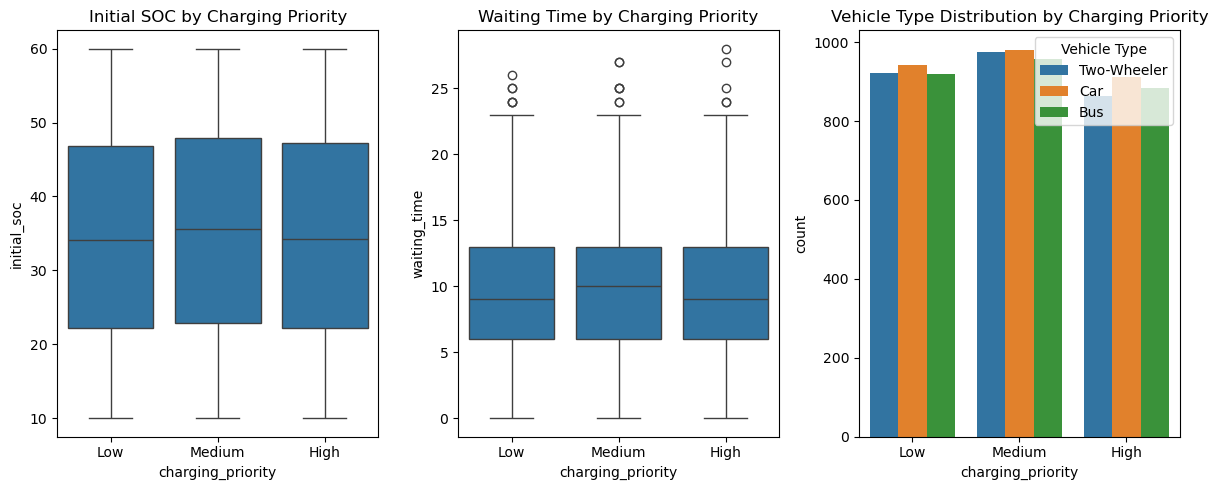

In [60]:
#Q6. s charging_priority (Low/Medium/High) influenced more by initial_soc, waiting_time, or vehicle_type?

plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
sns.boxplot(df_cleaned, x='charging_priority', y='initial_soc')
plt.title('Initial SOC by Charging Priority')
plt.subplot(1,3,2)
sns.boxplot(df_cleaned, x='charging_priority', y='waiting_time')
plt.title('Waiting Time by Charging Priority')
plt.subplot(1,3,3)
sns.countplot(df_cleaned, x='charging_priority', hue='vehicle_type')
plt.title('Vehicle Type Distribution by Charging Priority')
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

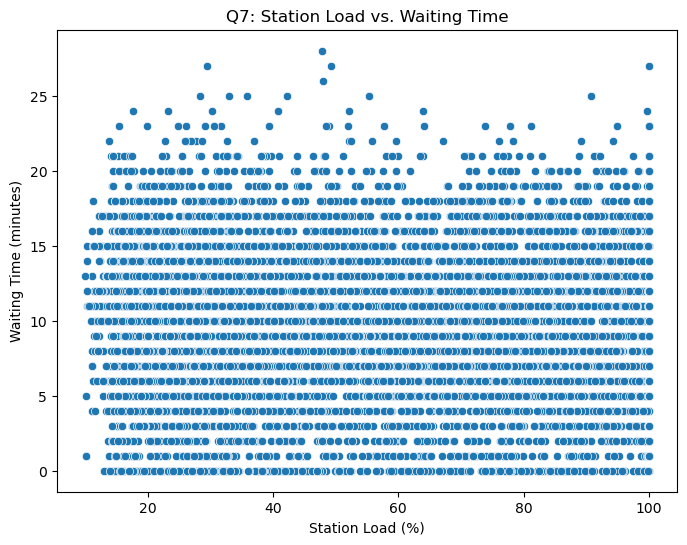

In [ ]:
#Q7. How does an increase in station_load affect the average waiting_time for incoming vehicles?
plt.figure(figsize=(8, 6))
sns.scatterplot(df_cleaned, x='station_load', y='waiting_time')
plt.title('Station Load vs. Waiting Time')
plt.xlabel('Station Load (%)')
plt.ylabel('Waiting Time (minutes)')
plt.show()

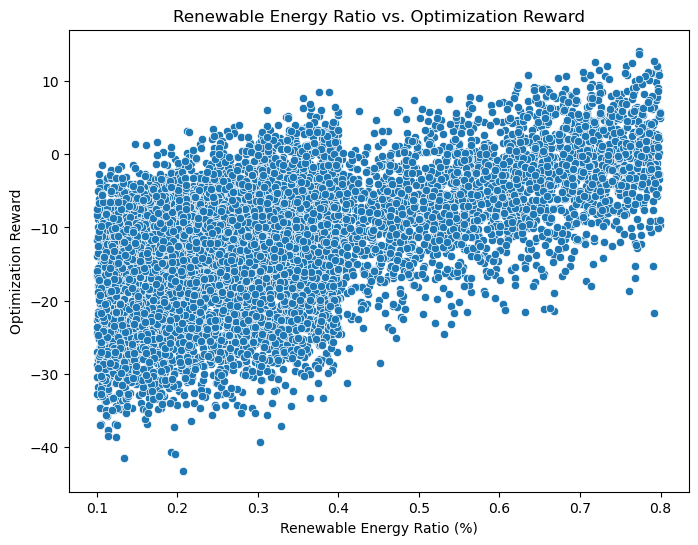

In [65]:
#Q8. Does a higher renewable_energy_ratio lead to a higher optimization_reward?

plt.figure(figsize=(8, 6))
sns.scatterplot(df_cleaned, x='renewable_energy_ratio', y='optimization_reward')
plt.title('Renewable Energy Ratio vs. Optimization Reward')
plt.xlabel('Renewable Energy Ratio (%)')
plt.ylabel('Optimization Reward')
plt.show()

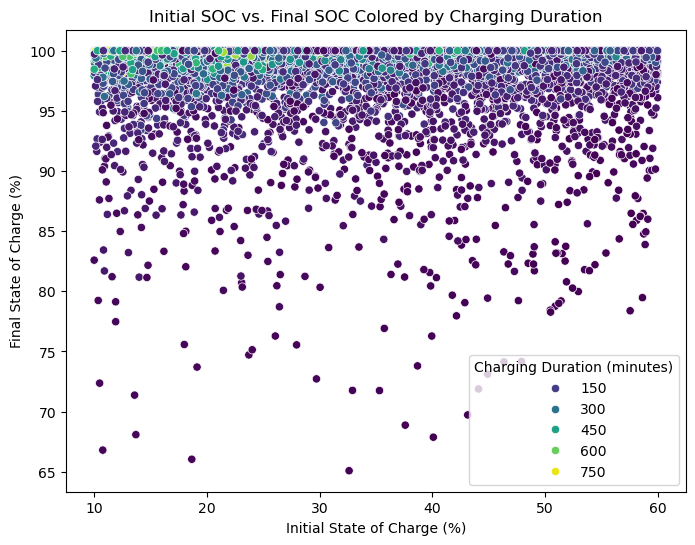

In [66]:
#Q9. What is the relationship between initial_soc and final_soc? Are most vehicles reaching 100%, or is there a cut-off point based on charging_duration?

plt.figure(figsize=(8, 6))
sns.scatterplot(df_cleaned, x='initial_soc', y='final_soc', hue='charging_duration', palette='viridis')
plt.title('Initial SOC vs. Final SOC Colored by Charging Duration')
plt.xlabel('Initial State of Charge (%)')
plt.ylabel('Final State of Charge (%)')
plt.legend(title='Charging Duration (minutes)')
plt.show()

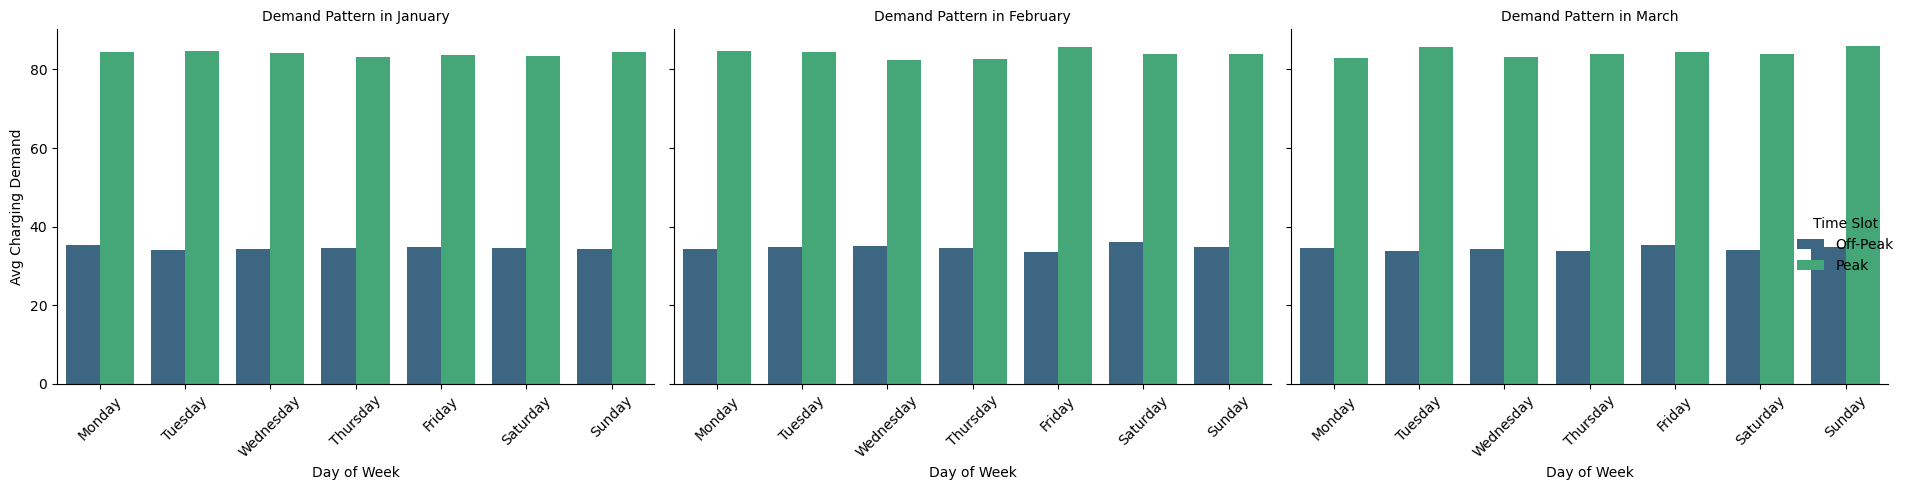

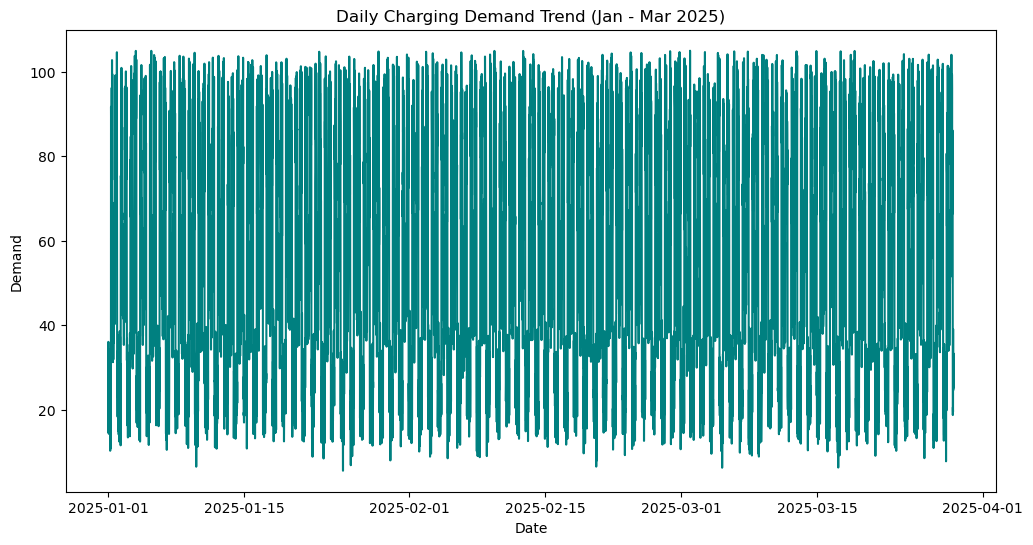

In [67]:
df_cleaned['timestamp'] = pd.to_datetime(df_cleaned['timestamp'])
df_cleaned['month'] = df_cleaned['timestamp'].dt.month_name()

# Define the logical order for the categories
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March']
# Note: Adjust 'Peak' categories based on your specific time_slot labels
time_order = ['Off-Peak', 'Mid-Peak', 'Peak'] 

# 2. Visualization: Faceted Bar Chart by Month
g = sns.FacetGrid(df_cleaned, col="month", col_order=month_order, height=5, aspect=1.2)
g.map_dataframe(sns.barplot, x="day_of_week", y="charging_demand", hue="time_slot", 
                order=days_order, hue_order=[t for t in time_order if t in df_cleaned['time_slot'].unique()],
                palette="viridis", errorbar=None)

g.add_legend(title="Time Slot")
g.set_axis_labels("Day of Week", "Avg Charging Demand")
g.set_titles("Demand Pattern in {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('monthly_demand_patterns.png')
plt.show()

# 3. Visualization: Overall Trend Line
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_cleaned, x='timestamp', y='charging_demand', color='teal')
plt.title('Daily Charging Demand Trend (Jan - Mar 2025)')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()